# So sánh PCA với các phương pháp giảm chiều khác

Bộ dữ liệu được sử dụng là Bộ dữ liệu nhận dạng chữ số viết tay (Digits dataset) có sẵn trong thư viện sklearn. Mỗi điểm dữ liệu là một bức ảnh 8x8 pixel (tương đương 64 chiều) của một chữ số từ 0 đến 9. Các nét chữ số cuộn xoắn, cong, đậm nhạt khác nhau tạo ra sự chồng chéo giữa các lớp sẽ tạo ra một không gian phi tuyến tính phức tạp. 

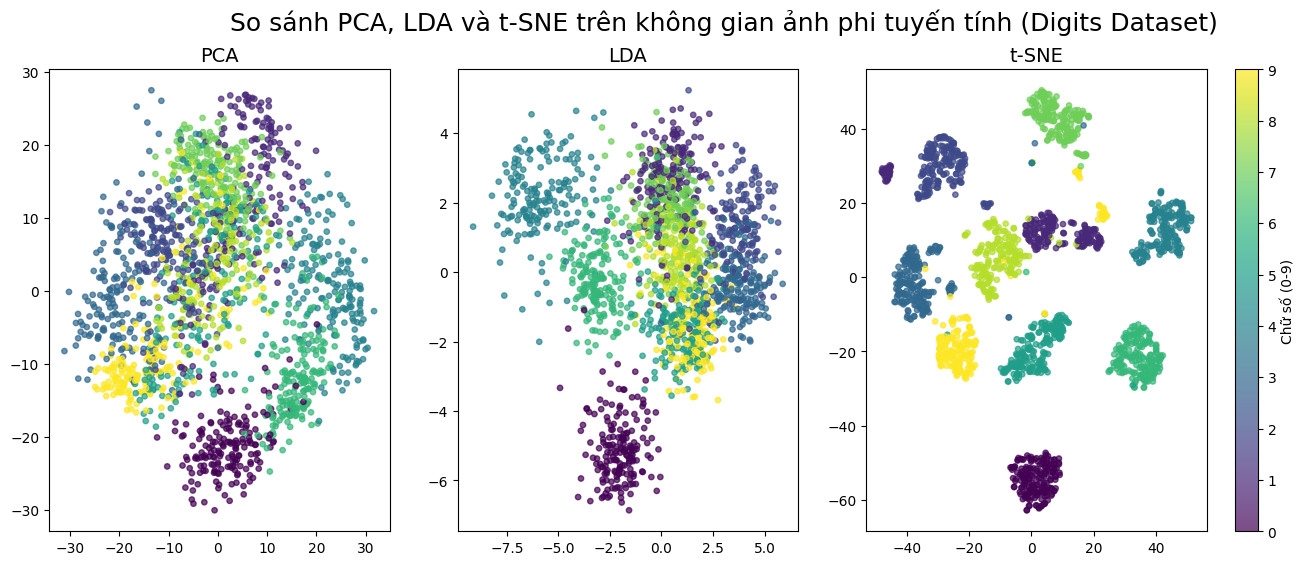

In [ ]:
import matplotlib.pyplot as plt
from sklearn import datasets
from sklearn.decomposition import PCA
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA
from sklearn.manifold import TSNE

# 1. Tải bộ dữ liệu chữ số viết tay (64 chiều, 10 class từ 0 đến 9)
digits = datasets.load_digits()
X = digits.data
y = digits.target

# 2. Khởi tạo 3 mô hình giảm chiều xuống 2D
pca = PCA(n_components=2)
lda = LDA(n_components=2)
tsne = TSNE(n_components=2, init="pca", learning_rate="auto", random_state=42)

# 3. Fit và Transform dữ liệu
X_pca = pca.fit_transform(X)
X_lda = lda.fit_transform(X, y)
X_tsne = tsne.fit_transform(X)

# 4. Trực quan hóa so sánh
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
# Sử dụng colormap "viridis" (chủ đạo dải màu xanh dương - xanh lá - vàng) cho 10 class
cmap = plt.get_cmap("viridis") 

# Plot PCA
scatter_pca = axes[0].scatter(X_pca[:, 0], X_pca[:, 1], c=y, cmap=cmap, alpha=0.7, s=15)
axes[0].set_title("PCA", fontsize=14)

# Plot LDA
scatter_lda = axes[1].scatter(X_lda[:, 0], X_lda[:, 1], c=y, cmap=cmap, alpha=0.7, s=15)
axes[1].set_title("LDA", fontsize=14)

# Plot t-SNE
scatter_tsne = axes[2].scatter(X_tsne[:, 0], X_tsne[:, 1], c=y, cmap=cmap, alpha=0.7, s=15)
axes[2].set_title("t-SNE", fontsize=14)

# Thêm thanh chú thích màu cho các chữ số
cbar = fig.colorbar(scatter_tsne, ax=axes.ravel().tolist(), ticks=range(10), pad=0.02)
cbar.set_label("Chữ số (0-9)")

plt.suptitle("So sánh PCA, LDA và t-SNE trên không gian ảnh phi tuyến tính (Digits Dataset)", fontsize=18)
plt.show()

Dựa vào kết quả giảm chiều, ta có thể nhận xét rằng:
- PCA: Do tính chất tuyến tính, PCA không thể tách biệt tốt các lớp chữ số, dẫn đến sự chồng chéo nặng giữa các lớp.
- LDA: Là một phương pháp có giám sát, LDA cố gắng tối đa hóa sự phân tách giữa các lớp. Tuy nhiên, do tính chất tuyến tính của nó, LDA cũng gặp khó khăn trong việc tách biệt các lớp chữ số phức tạp, mặc dù có phần tốt hơn PCA.
- t-SNE: Là một phương pháp phi tuyến và t-SNE có khả năng giữ được cấu trúc lân cận của dữ liệu, giúp tách biệt các lớp chữ số một cách rõ ràng hơn. Các lớp chữ số được phân cụm tốt hơn, cho thấy t-SNE là lựa chọn xuất sắc cho việc giảm chiều trong trường hợp này.

# Áp dụng PCA cho giảm tín hiệu nhiễu

Bài toán giảm tín hiệu nhiễu có bản chất tương tự với bài toán nén ảnh. Các điểm ảnh nhiễu tương tự với các chi tiết nhỏ/không quan trọng trong ảnh. Các điểm ảnh nhiễu khiến cho vector hàng của ảnh bị "lệch đi" so với bức ảnh chuẩn, do đó PCA sẽ tìm ra và "gán" cho những điểm ảnh này eigenvector nhỏ. Từ đó, PCA có thể giúp loại bỏ những chi tiết này bằng cách giữ lại các thành phần chính có phương sai lớn nhất, từ đó giảm nhiễu và khôi phục lại ảnh gốc tốt hơn.


**1. Khai báo các thư viện cần thiết**

In [7]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from sklearn.decomposition import PCA

**2. Đọc ảnh gốc và Tiền xử lý**
Chuyển ảnh về định dạng Grayscale (ảnh mức xám) để chuyển thành ma trận 2D, thuận tiện cho việc áp dụng PCA.

In [8]:
# Đọc ảnh và chuyển sang Grayscale
image = Image.open("dataset/panda_image_0032.jpg").convert("L")
X = np.array(image, dtype=np.float64)

print(f"Kích thước ảnh gốc: {X.shape}")

Kích thước ảnh gốc: (217, 300)


**3. Tạo nhiễu giả lập (Gaussian Noise)**
Cộng thêm nhiễu phân phối chuẩn vào ảnh gốc để tạo ra một bức ảnh bị mờ/lốm đốm, mô phỏng tín hiệu bị nhiễu trong thực tế.

In [9]:
noise_intensity = 30.0
noise = np.random.normal(loc=0.0, scale=noise_intensity, size=X.shape)
X_noisy = X + noise

# Ép các giá trị pixel về lại khoảng [0, 255] 
X_noisy = np.clip(X_noisy, 0, 255)

**4. Áp dụng PCA để lọc nhiễu**
Vì nhiễu mang tính ngẫu nhiên (phương sai nhỏ), trong khi thông tin ảnh mang cấu trúc chính (phương sai lớn). Ta sẽ dùng PCA giữ lại $k$ thành phần chính yếu nhất và vứt bỏ các thành phần đuôi chứa nhiễu.

In [10]:
# Chuẩn hóa
mean_vec_noisy = np.mean(X_noisy, axis=0)
X_noisy_centered = X_noisy - mean_vec_noisy

k = 50 
pca = PCA(n_components=k)

# Giảm chiều
X_reduced = pca.fit_transform(X_noisy_centered)

# Tái tạo
X_denoised = pca.inverse_transform(X_reduced) + mean_vec_noisy
X_denoised = np.clip(X_denoised, 0, 255)

**5. Trực quan hóa kết quả đánh giá**

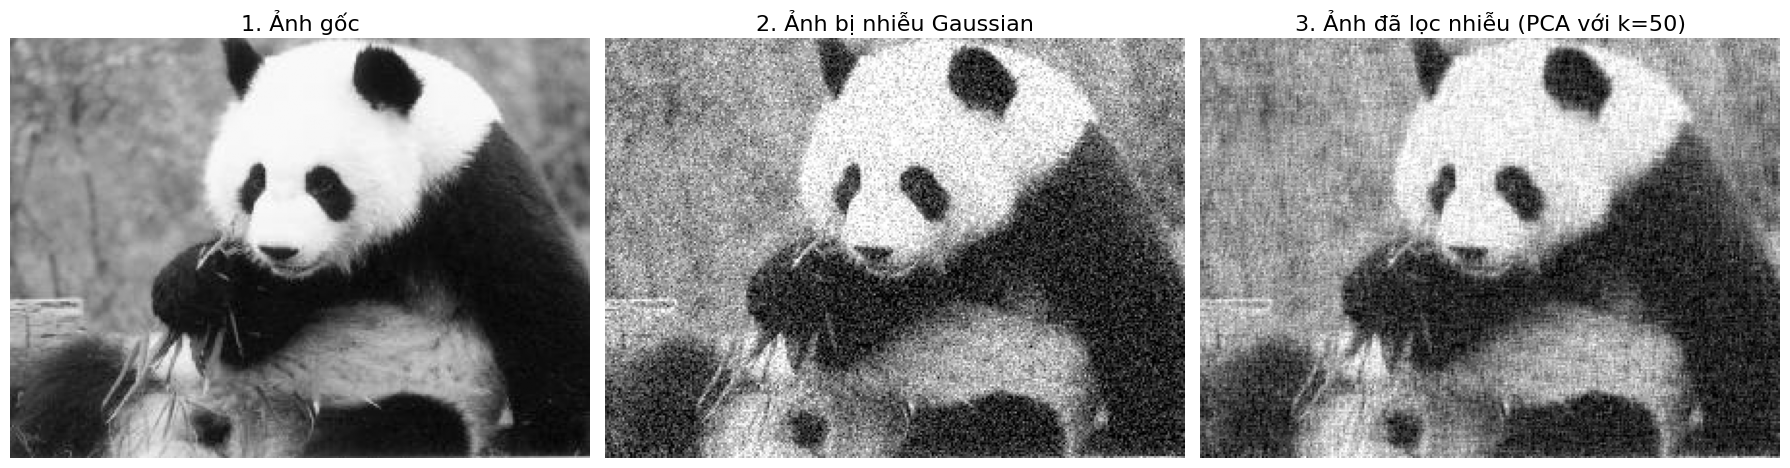

In [11]:
# Trực quan hóa kết quả để đưa vào báo cáo
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

axes[0].imshow(X, cmap="gray")
axes[0].set_title("1. Ảnh gốc", fontsize=16)
axes[0].axis("off")

axes[1].imshow(X_noisy, cmap="gray")
axes[1].set_title("2. Ảnh bị nhiễu Gaussian", fontsize=16)
axes[1].axis("off")

axes[2].imshow(X_denoised, cmap="gray")
axes[2].set_title(f"3. Ảnh đã lọc nhiễu (PCA với k={k})", fontsize=16)
axes[2].axis("off")

plt.tight_layout()
plt.show()